# 🧠 DermaAI Vision - Entrenamiento del Modelo CNN

Este notebook entrena un modelo de clasificación de enfermedades dermatológicas usando:
- **MobileNetV2** con Transfer Learning
- **Dataset ISIC** de Kaggle (estructura de carpetas)
- **7+ clases** de condiciones cutáneas

---

## 1. Configuración del Entorno

In [1]:
# Instalar kagglehub para descargar el dataset
!pip install kagglehub -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU disponible: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU disponible: []


## 2. Descarga del Dataset ISIC

In [2]:
import kagglehub

# Descargar el dataset de Kaggle
path = kagglehub.dataset_download("rajivaiml/isic-skin-cancer-dataset")
print(f"📁 Dataset descargado en: {path}")

100%|██████████| 786M/786M [00:12<00:00, 68.5MB/s]

Extracting files...


📁 Dataset descargado en: /root/.cache/kagglehub/datasets/rajivaiml/isic-skin-cancer-dataset/versions/1


In [3]:
# Encontrar la ruta correcta del dataset
# El dataset tiene estructura: base_path/Train/[clases] y base_path/Test/[clases]

# Buscar la carpeta que contiene Train y Test
base_path = None
for root, dirs, files in os.walk(path):
    if 'Train' in dirs and 'Test' in dirs:
        base_path = root
        break
    # También buscar variaciones comunes
    if 'train' in [d.lower() for d in dirs]:
        base_path = root
        break

if base_path is None:
    # Usar la ruta conocida del dataset ISIC
    base_path = os.path.join(path, "Skin cancer ISIC The International Skin Imaging Collaboration")

print(f"📁 Ruta base del dataset: {base_path}")
print(f"\n📂 Contenido:")
if os.path.exists(base_path):
    for item in os.listdir(base_path):
        full_path = os.path.join(base_path, item)
        if os.path.isdir(full_path):
            num_items = len(os.listdir(full_path))
            print(f"   📁 {item}/ ({num_items} elementos)")

📁 Ruta base del dataset: /root/.cache/kagglehub/datasets/rajivaiml/isic-skin-cancer-dataset/versions/1/Skin cancer ISIC The International Skin Imaging Collaboration

📂 Contenido:
   📁 Test/ (9 elementos)
   📁 Train/ (9 elementos)


In [4]:
# Definir rutas de Train y Test
TRAIN_DIR = os.path.join(base_path, "Train")
TEST_DIR = os.path.join(base_path, "Test")

# Verificar que existan
print(f"✅ Train existe: {os.path.exists(TRAIN_DIR)}")
print(f"✅ Test existe: {os.path.exists(TEST_DIR)}")

# Listar clases disponibles
if os.path.exists(TRAIN_DIR):
    classes = sorted(os.listdir(TRAIN_DIR))
    print(f"\n📊 Clases encontradas ({len(classes)}):")
    for i, cls in enumerate(classes):
        cls_path = os.path.join(TRAIN_DIR, cls)
        if os.path.isdir(cls_path):
            num_images = len([f for f in os.listdir(cls_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
            print(f"   {i+1}. {cls}: {num_images} imágenes")

✅ Train existe: True
✅ Test existe: True

📊 Clases encontradas (9):
   1. actinic keratosis: 114 imágenes
   2. basal cell carcinoma: 376 imágenes
   3. dermatofibroma: 95 imágenes
   4. melanoma: 438 imágenes
   5. nevus: 357 imágenes
   6. pigmented benign keratosis: 462 imágenes
   7. seborrheic keratosis: 77 imágenes
   8. squamous cell carcinoma: 181 imágenes
   9. vascular lesion: 139 imágenes


## 3. Configuración de Hiperparámetros

In [5]:
# ============================================
# CONFIGURACIÓN
# ============================================

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 15
LEARNING_RATE = 0.001

# Número de clases (se detectará automáticamente)
NUM_CLASSES = len([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])

print(f"📊 Configuración:")
print(f"   Número de clases: {NUM_CLASSES}")
print(f"   Tamaño de imagen: {IMG_SIZE}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Épocas: {EPOCHS}")
print(f"   Learning rate: {LEARNING_RATE}")

📊 Configuración:
   Número de clases: 9
   Tamaño de imagen: (224, 224)
   Batch size: 32
   Épocas: 15
   Learning rate: 0.001


## 4. Crear Generadores de Datos

In [6]:
# Data Augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range=0.2,
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.2  # 20% para validación
)

# Sin augmentation para validación/test
test_datagen = ImageDataGenerator(rescale=1./255)

# Generador de entrenamiento
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Generador de validación
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

# Generador de test
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"\n✅ Generadores creados!")
print(f"🏋️ Imágenes de entrenamiento: {train_generator.samples}")
print(f"🧪 Imágenes de validación: {val_generator.samples}")
print(f"📝 Imágenes de test: {test_generator.samples}")
print(f"\n📊 Clases: {list(train_generator.class_indices.keys())}")

Found 1795 images belonging to 9 classes.
Found 444 images belonging to 9 classes.
Found 118 images belonging to 9 classes.

✅ Generadores creados!
🏋️ Imágenes de entrenamiento: 1795
🧪 Imágenes de validación: 444
📝 Imágenes de test: 118

📊 Clases: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


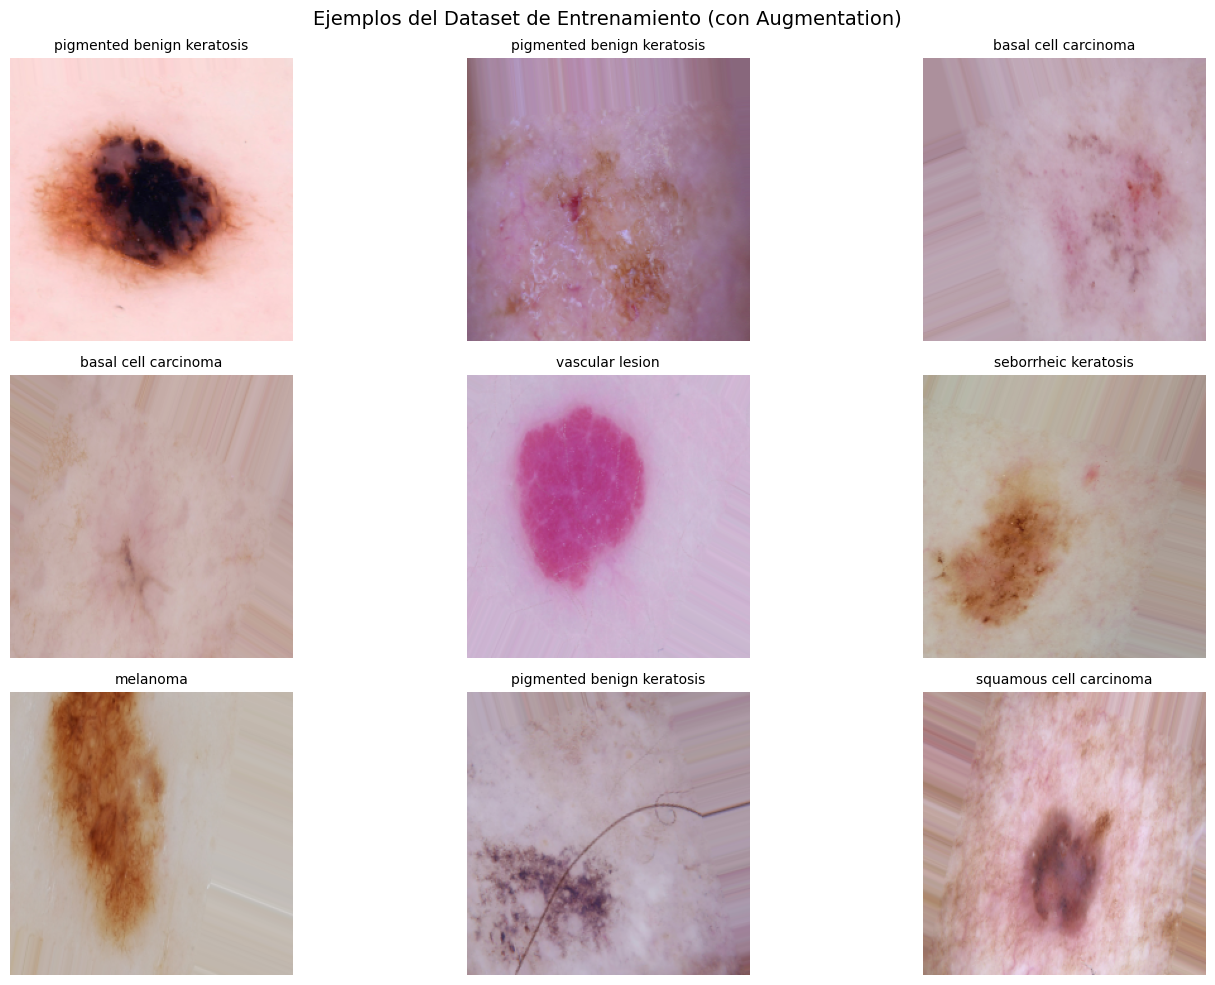

In [7]:
# Visualizar ejemplos del dataset
plt.figure(figsize=(15, 10))
x_batch, y_batch = next(train_generator)

class_names = list(train_generator.class_indices.keys())

for i in range(min(9, len(x_batch))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_batch[i])
    class_idx = np.argmax(y_batch[i])
    plt.title(class_names[class_idx], fontsize=10)
    plt.axis('off')


plt.suptitle('Ejemplos del Dataset de Entrenamiento (con Augmentation)', fontsize=14)
plt.tight_layout()
plt.show()

## 5. Calcular Pesos de Clase (Manejo de Desbalance)

In [8]:
# Contar imágenes por clase para calcular pesos
class_counts = {}
for class_name in train_generator.class_indices.keys():
    class_path = os.path.join(TRAIN_DIR, class_name)
    count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    class_counts[class_name] = count

print("📊 Distribución de clases en Train:")
for cls, count in sorted(class_counts.items(), key=lambda x: x[1], reverse=True):
    print(f"   {cls}: {count} imágenes")

# Calcular pesos
total = sum(class_counts.values())
class_weight_dict = {}

for class_name, idx in train_generator.class_indices.items():
    # Peso inversamente proporcional a la frecuencia
    class_weight_dict[idx] = total / (len(class_counts) * class_counts[class_name])

print("\n⚖️ Pesos de clase calculados:")
for class_name, idx in train_generator.class_indices.items():
    print(f"   {class_name}: {class_weight_dict[idx]:.3f}")

📊 Distribución de clases en Train:
   pigmented benign keratosis: 462 imágenes
   melanoma: 438 imágenes
   basal cell carcinoma: 376 imágenes
   nevus: 357 imágenes
   squamous cell carcinoma: 181 imágenes
   vascular lesion: 139 imágenes
   actinic keratosis: 114 imágenes
   dermatofibroma: 95 imágenes
   seborrheic keratosis: 77 imágenes

⚖️ Pesos de clase calculados:
   actinic keratosis: 2.182
   basal cell carcinoma: 0.662
   dermatofibroma: 2.619
   melanoma: 0.568
   nevus: 0.697
   pigmented benign keratosis: 0.538
   seborrheic keratosis: 3.231
   squamous cell carcinoma: 1.374
   vascular lesion: 1.790


## 6. Construir el Modelo CNN

In [9]:
def build_dermaai_model(num_classes, freeze_base=True):
    """
    Construye el modelo DermaAI usando MobileNetV2 como base.
    """
    # Cargar MobileNetV2 pre-entrenado
    base_model = MobileNetV2(
        input_shape=(224, 224, 3),
        include_top=False,
        weights='imagenet'
    )

    # Congelar la base
    base_model.trainable = not freeze_base

    # Modelo completo
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

# Construir el modelo
model = build_dermaai_model(num_classes=NUM_CLASSES)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │         2,313 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,594,377 (9.90 MB)

 Trainable params: 333,321 (1.27 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

## 7. Entrenar el Modelo

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'dermaai_best_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Iniciando entrenamiento...\n")

🚀 Iniciando entrenamiento...



In [11]:
# Entrenar
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2036 - loss: 2.7057
Epoch 1: val_accuracy improved from -inf to 0.43243, saving model to dermaai_best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 153s 2s/step - accuracy: 0.2044 - loss: 2.7014 - val_accuracy: 0.4324 - val_loss: 1.6122 - learning_rate: 0.0010
Epoch 2/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3360 - loss: 1.9713
Epoch 2: val_accuracy improved from 0.43243 to 0.43919, saving model to dermaai_best_model.keras
57/57 ━━━━━━━━━━━━━━━━━━━━ 135s 2s/step - accuracy: 0.3359 - loss: 1.9706 - val_accuracy: 0.4392 - val_loss: 1.6118 - learning_rate: 0.0010
Epoch 3/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3708 - loss: 1.7400
Epoch 3: val_accuracy did not improve from 0.43919
57/57 ━━━━━━━━━━━━━━━━━━━━ 152s 3s/step - accuracy: 0.3707 - loss: 1.7399 - val_accuracy: 0.4279 - val_loss: 1.6131 - learning_rate: 0.0010
Epoch 4/15
57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4062 - loss: 1.6429
Epoch 

## 8. Visualizar Resultados

/tmp/ipython-input-211810206.py:22: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-211810206.py:22: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-211810206.py:23: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150)
/tmp/ipython-input-211810206.py:23: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('training_curves.png', dpi=150)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(

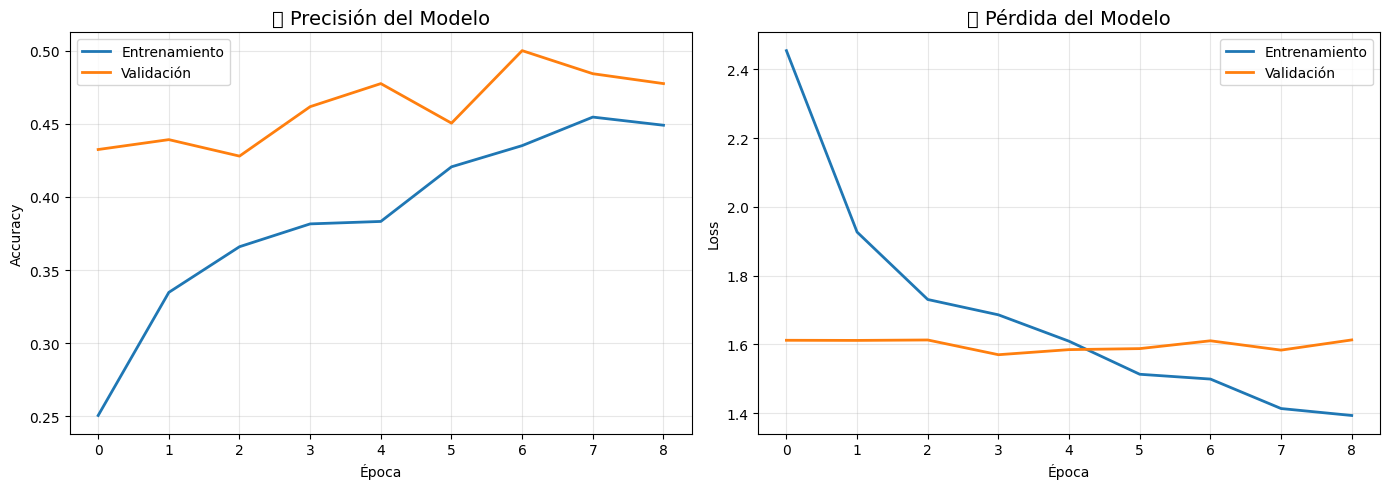


✅ Mejor accuracy de validación: 0.5000


In [12]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
axes[0].plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validación', linewidth=2)
axes[0].set_title('📈 Precisión del Modelo', fontsize=14)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history.history['loss'], label='Entrenamiento', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validación', linewidth=2)
axes[1].set_title('📉 Pérdida del Modelo', fontsize=14)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

print(f"\n✅ Mejor accuracy de validación: {max(history.history['val_accuracy']):.4f}")

## 9. Evaluar en Test

In [13]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Evaluar en test
print("📊 Evaluando en conjunto de Test...")
test_loss, test_acc = model.evaluate(test_generator, verbose=1)
print(f"\n✅ Test Accuracy: {test_acc:.4f}")
print(f"✅ Test Loss: {test_loss:.4f}")

📊 Evaluando en conjunto de Test...


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.3210 - loss: 1.9175

✅ Test Accuracy: 0.3729
✅ Test Loss: 1.7769


4/4 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step


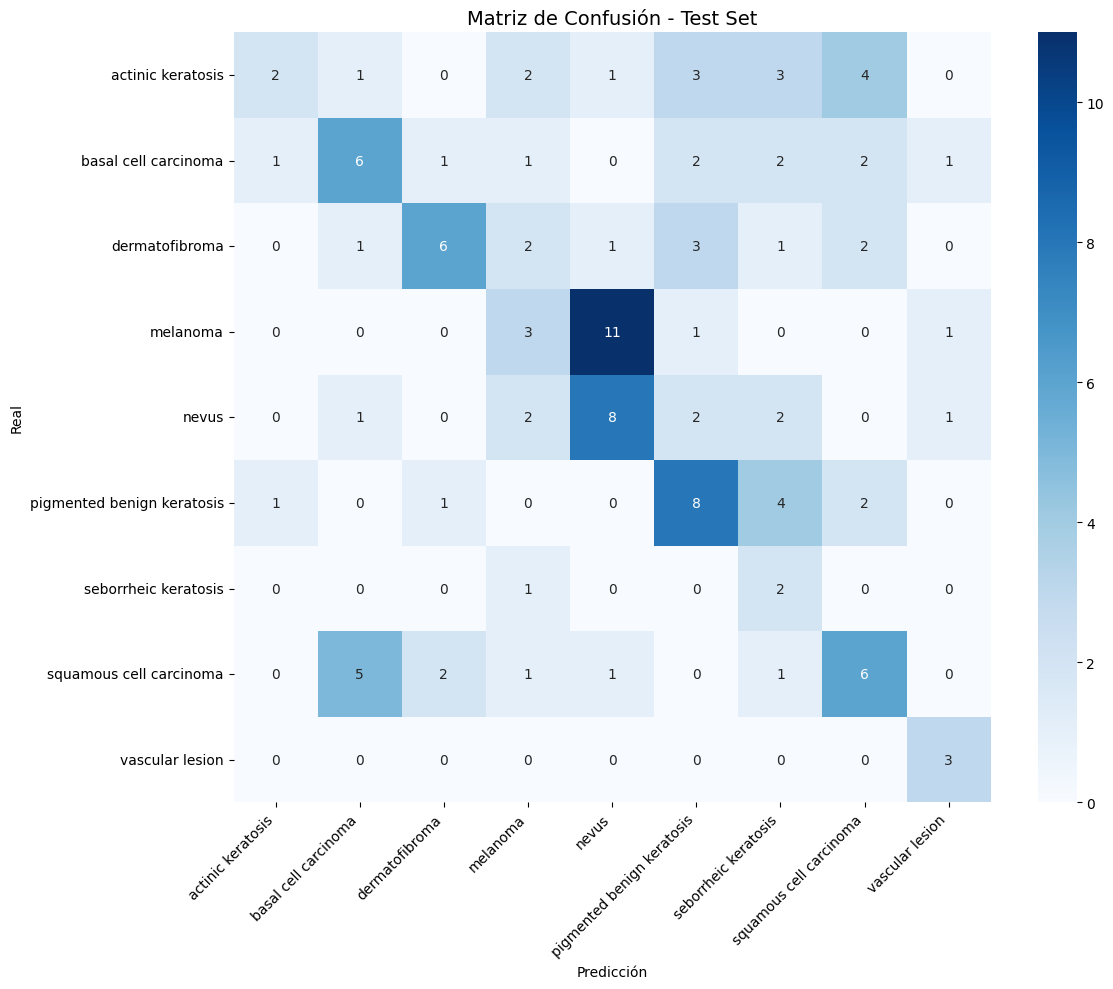

In [14]:
# Predicciones y matriz de confusión
test_generator.reset()
predictions = model.predict(test_generator, verbose=1)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

# Matriz de confusión
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - Test Set', fontsize=14)
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

In [15]:
# Reporte de clasificación
print("📊 Reporte de Clasificación:\n")
print(classification_report(y_true, y_pred, target_names=class_names))

📊 Reporte de Clasificación:

                            precision    recall  f1-score   support

         actinic keratosis       0.50      0.12      0.20        16
      basal cell carcinoma       0.43      0.38      0.40        16
            dermatofibroma       0.60      0.38      0.46        16
                  melanoma       0.25      0.19      0.21        16
                     nevus       0.36      0.50      0.42        16
pigmented benign keratosis       0.42      0.50      0.46        16
      seborrheic keratosis       0.13      0.67      0.22         3
   squamous cell carcinoma       0.38      0.38      0.38        16
           vascular lesion       0.50      1.00      0.67         3

                  accuracy                           0.37       118
                 macro avg       0.40      0.46      0.38       118
              weighted avg       0.41      0.37      0.37       118



## 10. Guardar el Modelo

In [16]:
# Guardar modelo
model.save('dermaai_model_final.keras')
print("✅ Modelo guardado como 'dermaai_model_final.keras'")

model.save('dermaai_model_final.h5')
print("✅ Modelo guardado como 'dermaai_model_final.h5'")

# Guardar información de clases
import json

class_info = {
    'class_indices': train_generator.class_indices,
    'class_names': list(train_generator.class_indices.keys()),
    'num_classes': len(train_generator.class_indices)
}

with open('class_info.json', 'w') as f:
    json.dump(class_info, f, indent=2)

print("✅ Información de clases guardada en 'class_info.json'")
print(f"\n📋 Clases: {class_info['class_names']}")

✅ Modelo guardado como 'dermaai_model_final.keras'
✅ Modelo guardado como 'dermaai_model_final.h5'
✅ Información de clases guardada en 'class_info.json'

📋 Clases: ['actinic keratosis', 'basal cell carcinoma', 'dermatofibroma', 'melanoma', 'nevus', 'pigmented benign keratosis', 'seborrheic keratosis', 'squamous cell carcinoma', 'vascular lesion']


## 11. Descargar Archivos

In [17]:
# Descargar en Colab
try:
    from google.colab import files

    print("📥 Descargando archivos...")
    files.download('dermaai_model_final.keras')
    files.download('dermaai_model_final.h5')
    files.download('class_info.json')
    files.download('training_curves.png')
    files.download('confusion_matrix.png')
    print("✅ Descarga completada!")
except:
    print("⚠️ No estás en Colab. Archivos guardados localmente:")
    for f in ['dermaai_model_final.keras', 'dermaai_model_final.h5', 'class_info.json']:
        if os.path.exists(f):
            size = os.path.getsize(f) / (1024*1024)
            print(f"   ✓ {f} ({size:.2f} MB)")

📥 Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Descarga completada!


---

## ✅ ¡Entrenamiento Completado!

### Próximos pasos:
1. Descarga los archivos a tu PC
2. Colócalos en la carpeta `models/`
3. Ejecuta el notebook `02_Train_RL_Agent.ipynb`
4. Inicia el servidor Flask: `python backend/app.py`